## Title: Employee Attrition Prediction

### Problem Statement:
A company is experiencing high employee turnover,
leading to increased recruitment costs and a negative impact on
productivity. The goal is to build a predictive model to identify employees at
risk of attrition and implement retention strategies.


### Objectives:
1. Develop a machine learning model to predict employee attrition.
2. Identify factors contributing to employee turnover.
3. Provide actionable recommendations for employee retention.

### Goals:
1. Achieve a classification accuracy of at least 85%.
2. Identify the top three factors contributing to employee attrition.
3. Provide retention strategies based on model insights.

### Scope:
1. Data analysis and preprocessing.
2. Feature engineering and model development.
3. Model evaluation and interpretation.
4. Recommendations for employee retention.

### Key Tasks:
1. Analyze historical employee data, including demographics and
performance metrics.
2. Preprocess data, handling missing values and encoding categorical
variables.
3. Engineer features related to employee satisfaction and engagement.
4. Build a classification model for predicting employee attrition.
5. Evaluate and interpret the model's performance.

### Importing Necessary Libraries

In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn
from collections import Counter
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , StratifiedKFold , RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN , SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier , AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report , precision_recall_curve , roc_auc_score , roc_curve

#### Basic settings

In [2]:
sns.set_theme(
    style = "whitegrid",
    palette = "colorblind",
    context = "talk"
)

plt.style.use("seaborn-v0_8")

plt.rcParams.update(
    {
        "axes.titlesize" : 12,
        "axes.labelsize" : 8,
        "axes.grid" : True,
        "lines.linewidth" : 4,
        "font.size" : 3
    }
)

np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4}".format)

### Dataset Description:
**Employee Attrition Prediction Dataset**

The Employee Attrition Prediction Dataset contains data for 10,000 employees, designed for predictive modeling and analysis of employee attrition. It includes a variety of demographic, job-related, and performance metrics to help understand the factors contributing to employee turnover.

Key Features:

1. **Employee_ID:** Unique identifier for each employee.

2. **Age:** Age of the employee.

3. **Gender:** Gender of the employee.

4. **Marital_Status:** Marital status of the employee (Single, Married, Divorced).

5. **Department:** Department the employee works in (e.g., HR, IT, Sales, Marketing).

6. **Job_Role:** Specific role within the department (e.g., Manager, Analyst).

7. **Job_Level:** Level in the organizational hierarchy.

8. **Monthly_Income:** Monthly salary of the employee.

9. **Hourly_Rate:** Rate per hour for hourly employees.

10. **Years_at_Company:** Number of years the employee has been with the company.

11. **Years_in_Current_Role:** Number of years the employee has been in their current role.

12. **Years_Since_Last_Promotion:** Time since the employee’s last promotion.

13. **Work_Life_Balance:** Rating of work-life balance.

14. **Job_Satisfaction:** Rating of job satisfaction (1-5 scale).

15. **Performance_Rating:** Performance rating (1-5 scale).

16. **Training_Hours_Last_Year:** Number of training hours completed in the past year.

17. **Overtime:** Whether the employee works overtime (Yes/No).

18. **Project_Count:** Number of projects managed by the employee.

19. **Average_Hours_Worked_Per_Week:** Average working hours per week.

20. **Absenteeism:** Number of days the employee was absent in the past year.

21. **Work_Environment_Satisfaction:** Rating of work environment satisfaction.

22. **Relationship_with_Manager:** Rating of the relationship with the manager.

23. **Job_Involvement:** Rating of job involvement.

24. **Distance_From_Home:** Distance from home to the workplace (in kilometers).

25. **Number_of_Companies_Worked:** Total number of companies the employee has worked for.

26. **Attrition:** The target column (Yes/No) indicating whether the employee left the company.

**Domain:** Finance

**Data Source:** Kaggle 

**Link:** https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset?select=employee_attrition_dataset_10000.csv


### Loading dataset And Initial Exploration

In [3]:
os.getcwd()

'C:\\Users\\KISHORE\\Uptricks_project'

In [4]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Uptricks")

In [5]:
employees_data = pd.read_csv("employee_attrition_dataset_10000.csv")
employees_data.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [6]:
employees_data.shape

(10000, 26)

In [7]:
employees_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

### Data Preprocessing

#### i) Duplicate Records

In [8]:
employees_data[employees_data.duplicated()]

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition


In [9]:
employees_data.duplicated().sum()

np.int64(0)

#### ii) Null Records

In [10]:
employees_data.isnull().sum()

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

<Axes: >

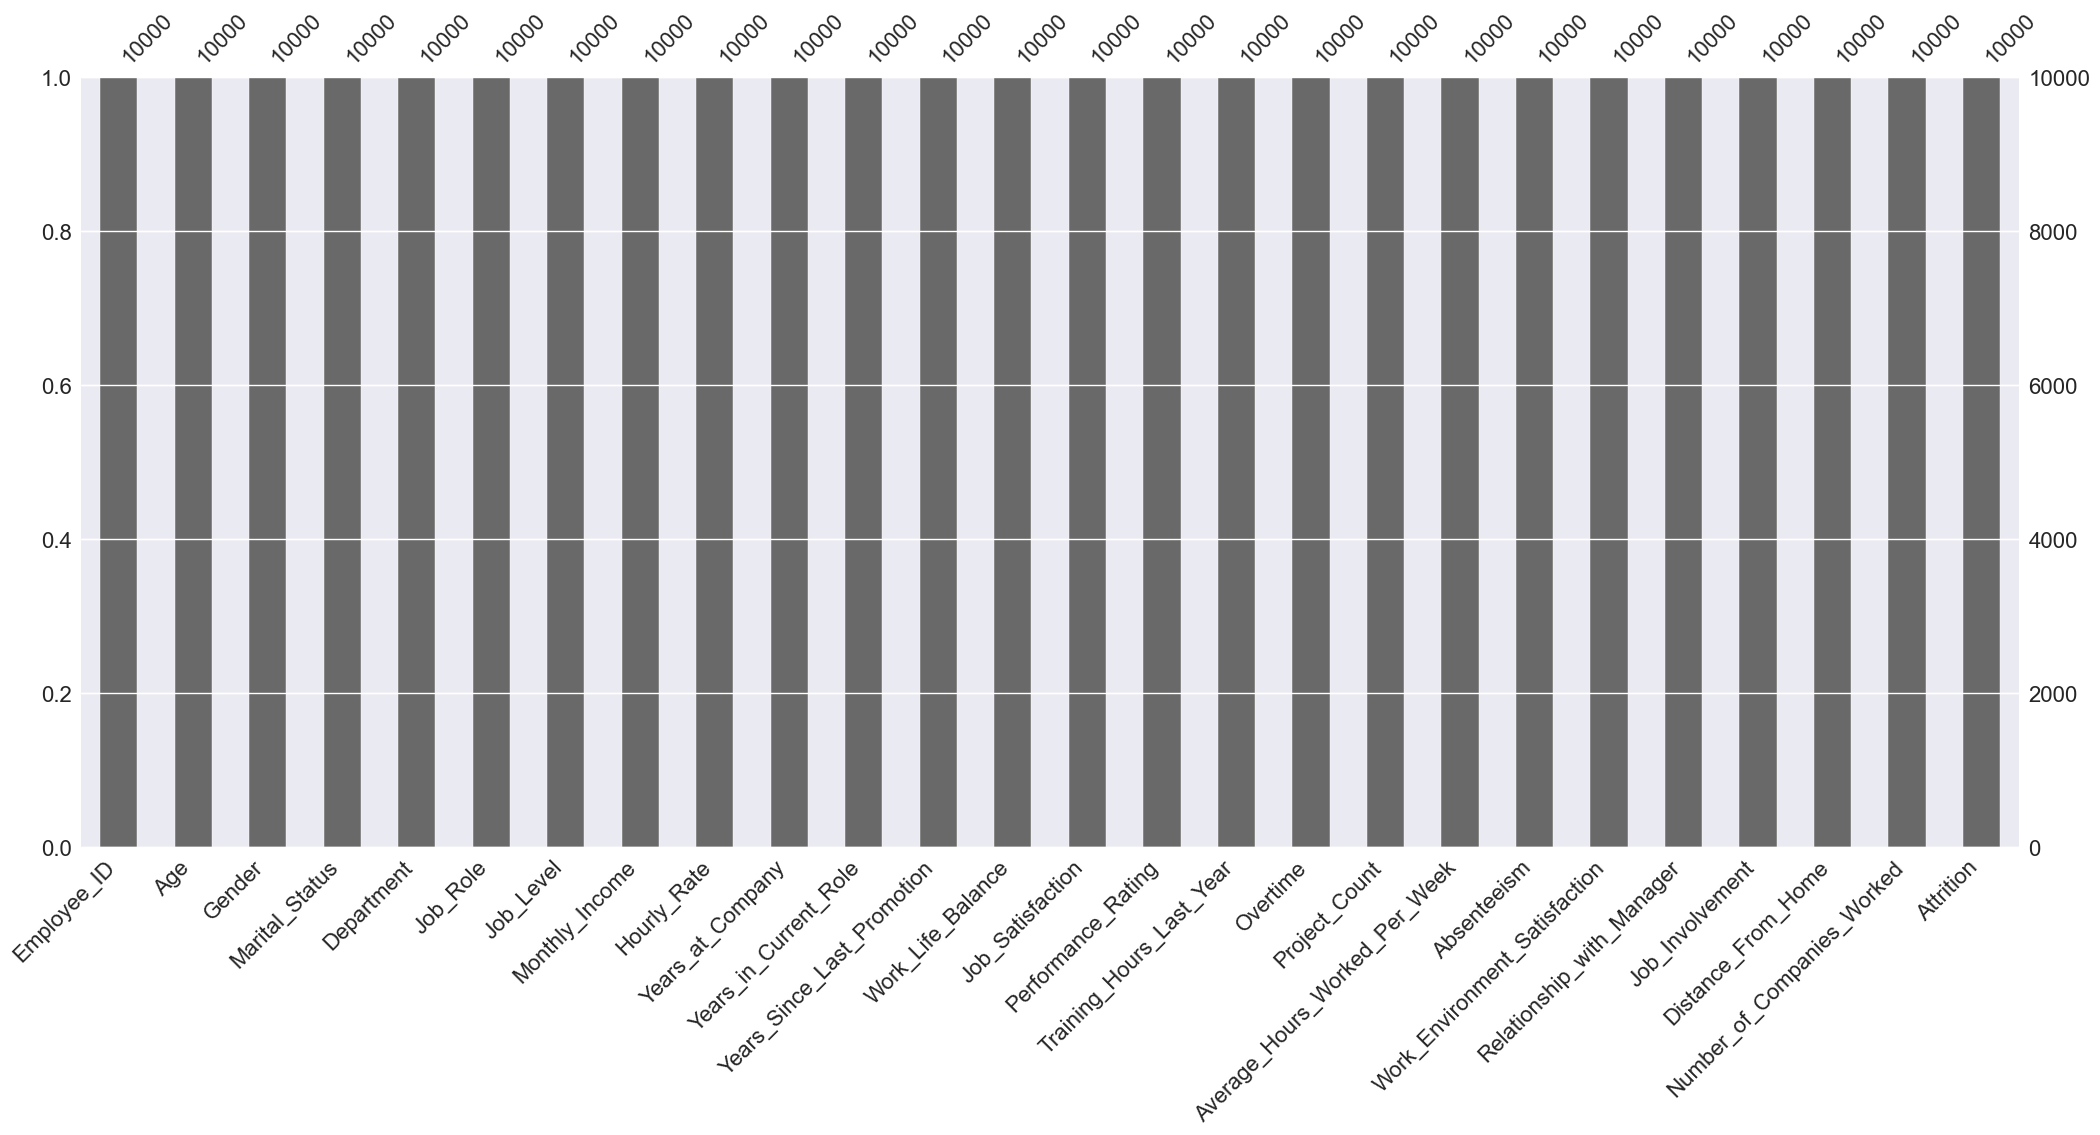

In [11]:
msn.bar(employees_data)

<Axes: >

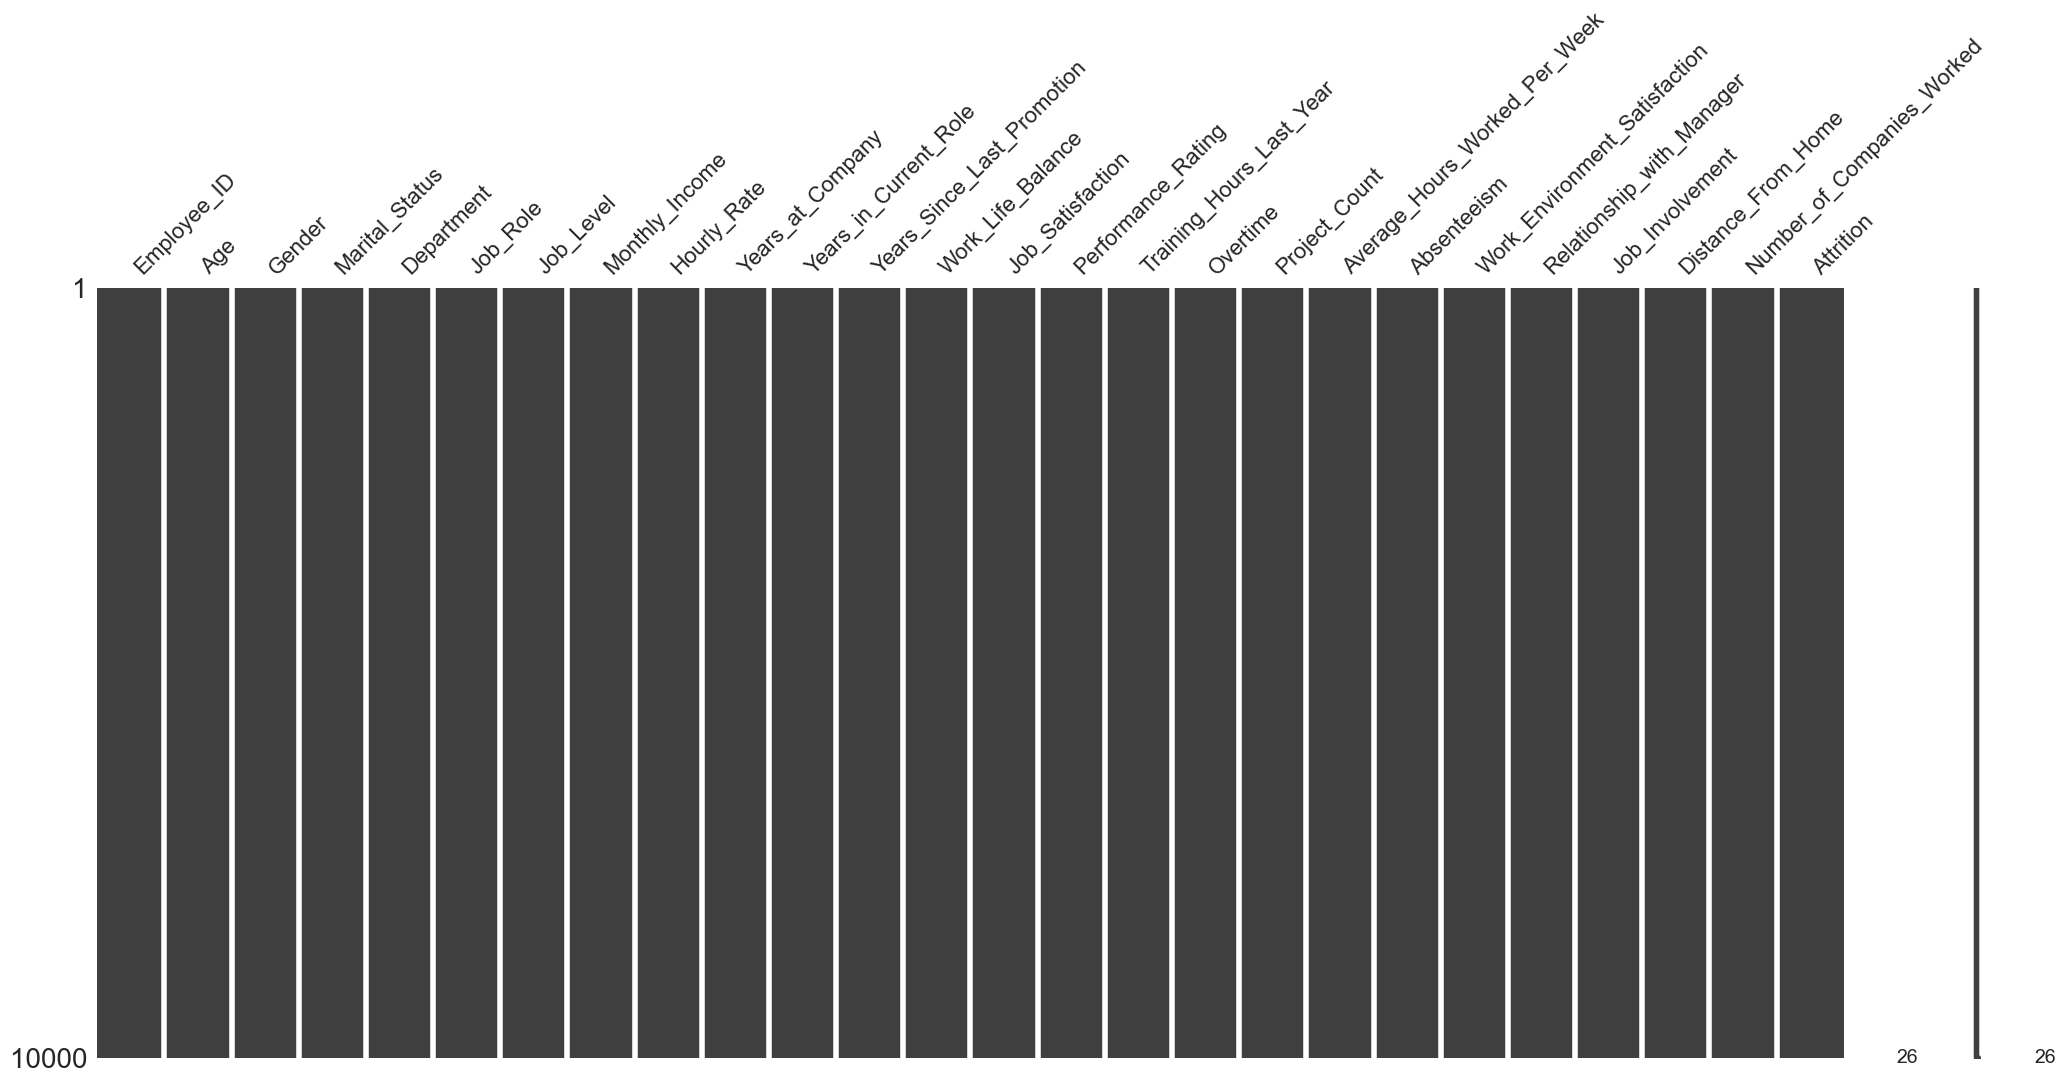

In [12]:
msn.matrix(employees_data)

#### iii) Inconsistent Data types And Formating

In [13]:
employees_data.columns = employees_data.columns.str.strip()

In [14]:
employees_data.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

### Exploratory Data Analysis (EDA)

#### i) Univariate Analysis(Destributions)

#### a) Numerical features

In [15]:
num_cols = employees_data.select_dtypes(include = "int64").columns
print(len(num_cols))
num_cols

20


Index(['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked'],
      dtype='object')

In [16]:
employees_data[num_cols].describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04,1e+04
mean,5e+03,39.56,2.991,1.144e+04,57.03,14.94,7.451,4.472,2.502,3.038,2.508,49.59,4.984,44.47,9.41,2.493,2.491,2.505,25.27,2.517
std,2.887e+03,11.45,1.411,4.927e+03,24.7,8.432,4.043,2.892,1.112,1.415,1.121,28.8,2.58,8.612,5.76,1.121,1.115,1.116,14.22,1.114
min,1.0,20.0,1.0,3e+03,15.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,30.0,0.0,1.0,1.0,1.0,1.0,1.0
25%,2.501e+03,30.0,2.0,7.182e+03,36.0,8.0,4.0,2.0,2.0,2.0,2.0,25.0,3.0,37.0,4.0,1.0,1.0,2.0,13.0,2.0
50%,5e+03,40.0,3.0,1.14e+04,57.0,15.0,7.0,4.0,2.0,3.0,3.0,49.0,5.0,45.0,9.0,2.0,2.0,3.0,25.0,2.0
75%,7.5e+03,49.0,4.0,1.568e+04,78.0,22.0,11.0,7.0,3.0,4.0,4.0,75.0,7.0,52.0,14.0,4.0,3.0,3.0,37.0,4.0
max,1e+04,59.0,5.0,2e+04,99.0,29.0,14.0,9.0,4.0,5.0,4.0,99.0,9.0,59.0,19.0,4.0,4.0,4.0,49.0,4.0


In [17]:
cat_cols = employees_data.select_dtypes(include = "object").columns
print(len(cat_cols))
cat_cols

6


Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')

In [18]:
employees_data[cat_cols].describe()

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
count,10000,10000,10000,10000,10000,10000
unique,2,3,5,4,2,2
top,Female,Married,Marketing,Analyst,No,No
freq,5042,3375,2133,2572,5103,8003


In [19]:
employees_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

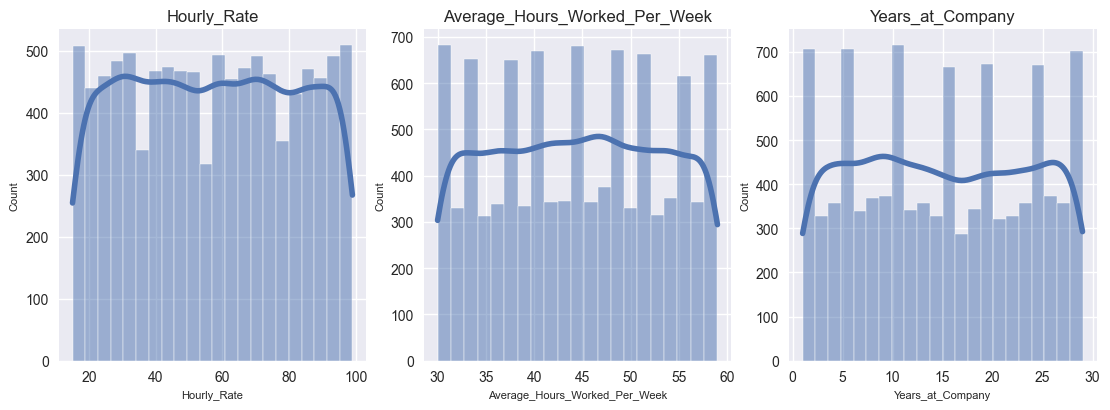

In [20]:
cols = ["Hourly_Rate" , "Average_Hours_Worked_Per_Week" ,"Years_at_Company"]
fig , axes = plt.subplots(1 , 3 , figsize = (11 , 4))
axes = axes.flatten()

for i , col in enumerate(cols):
    sns.histplot(x = employees_data[col] , kde = True , ax = axes[i])

    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

##### Examine Employees Hourly rate data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Horly_Rate feature is Numerical continuous data type. 
- in employees dataset , the feature Hourly rate of all employees data have low variability (value are varing by ~₹24.7 from mean or median).
- most of the hourly rate of all employees is around the center value (mean = ₹57.03 , meadin = ₹50.0) , data is highly concentrated around the center value.
- range of minimum Hourly_Rate ~₹15.0 to below center valued employees are around ~₹36.0 Hourly_Rate , similarly above central value to maximum Hourly_rate ~₹99.0 are around ~₹78.0 employees are earning.
- it not not have any outliers

##### Examine Employees Average_Hours_Worked_Per_Week data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Average_Hours_Worked_Per_Week feature is Numerical continuous data type.
- Average number of Hours worked Per Week of all employees data have low variability (value are varing by ~9 hourse from center value).
- Data Concentration around center values mean = ~44 Hourse , medain = ~45 hourse.
- lower valued hourse worked are around ~37 hourse and high valued worked values around ~52 hourse.
- it not not have any outliers

##### Examine Employees Years_at_Company data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Years_at_Company feature is Numerical continuous data type.
- it is also have low variability (value are varing by 8 number of years from mean or median).
- Data Concentration highly around center values mean = 15 years , medain = 15 years of employees at company.
- low number of year worked employees around 8 year from minimum to center and higher number years at comapny employees are around 22 years from center to maximum.
- it not not have any outliers

This three features Horly_Rate , Average_Hours_Worked_Per_Week , Years_at_Company are important for employee attrition analysis.

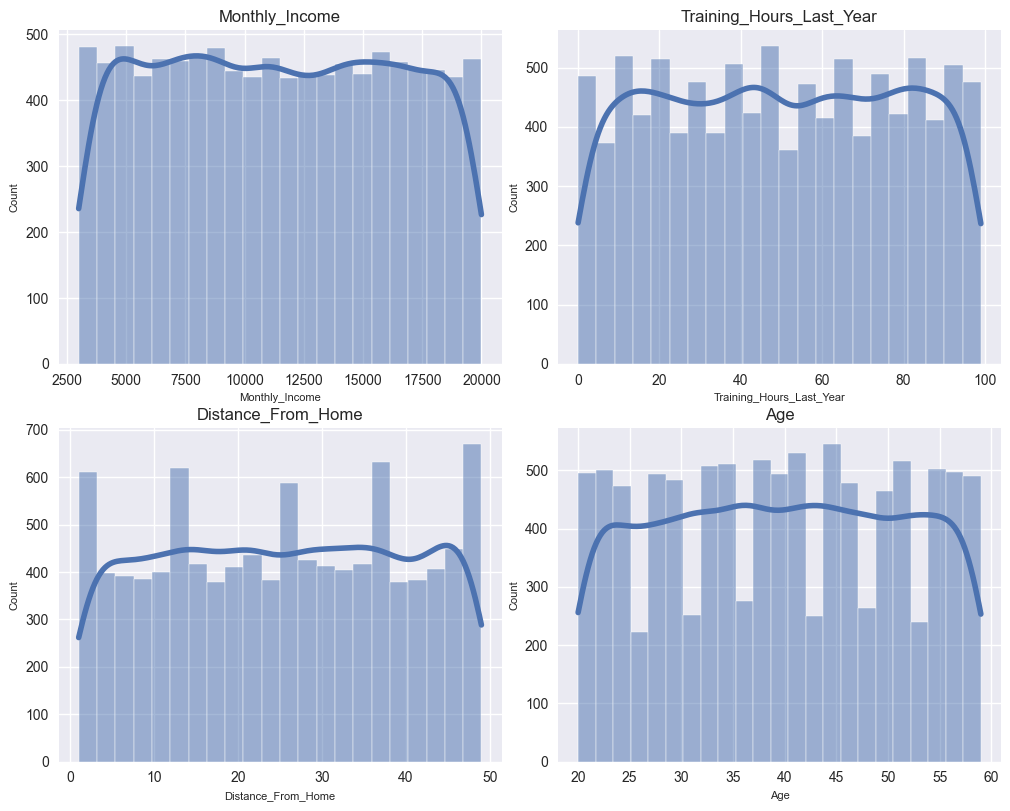

In [21]:
cols = ["Monthly_Income" , "Training_Hours_Last_Year" ,"Distance_From_Home" , "Age"]
fig , axes = plt.subplots(2 , 2 , figsize = (10 , 8))
axes = axes.flatten()

for i , col in enumerate(cols):
    sns.histplot(x = employees_data[col] , kde = True , ax = axes[i])

    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

##### Examine Employees Monthly Income data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Monthly Income feature is Numerical continuous data type.'
- employees monthly income is also low variability in its destribution , salary is varing by ₹4,927 from center of the data.
- Salary Data Concentration highly lies around center values mean = ₹11,440 , medain = ₹11,400 of employees in company.
- lower 25% salary data is around ₹7,182 and upper 25%  around ₹15,680

##### Examine Employees Training Hours Last Year data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Training_Hours_Last_Year feature is Numerical continuous data type.
- Training_Hours_Last_Year have high variability by ~29 hourse from center value of the data.
- most of the data lies around the typical center values mean = ~49 hours ,median =  ~49 hours
- lower 25% salary data is around 25 hourse and upper 25%  around 75 hourse respectivily.

##### Examine Employees Distance From Home data Destribution:

we can see above histogram plot and Summary table of Hourly_Rate feature
- Distance_From_Home feature is Numerical continuous data type.
- it have high variability by ~14 km from center value of the data.
- most of the data lies around the typical center values mean = ~25.27 km ,median =  ~25 km.
- lower 25% salary data is around 13km and upper 25%  around 735km respectivily.

##### Examine Employees Age data Destribution:

we can see above histogram plot and Summary table of Age feature
- Age feature is Numerical continuous data type.
- it low variability in data about varing by ~1 years from center of the data.
- high data concentration lies arournd the center of the data

among this foure features Monthly Income and Age are important for analysis than Training Hours Last Year , Distance From Home.

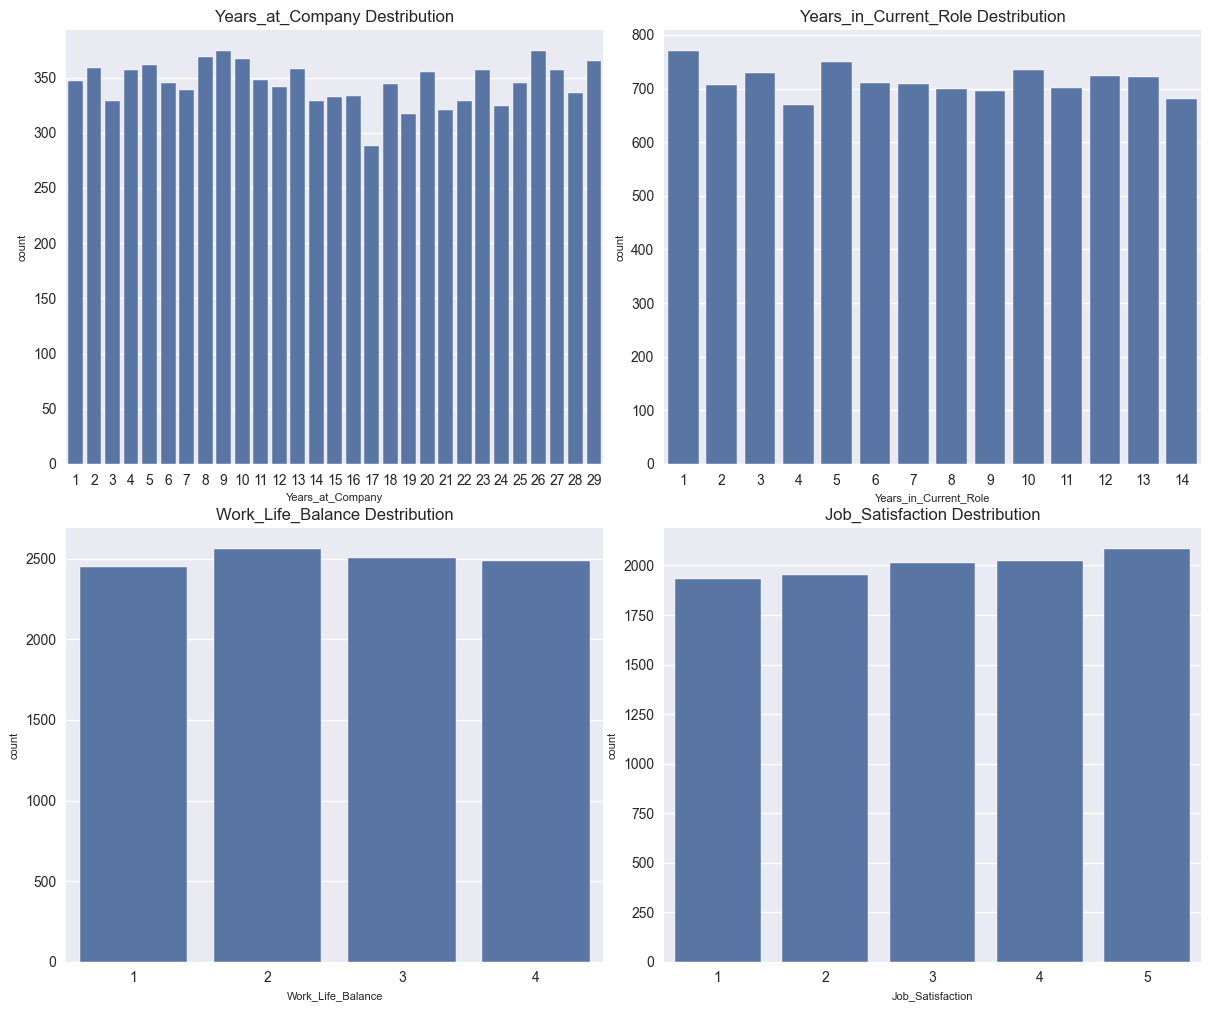

In [22]:
cols = ["Years_at_Company" , "Years_in_Current_Role" ,"Work_Life_Balance" , "Job_Satisfaction"]
fig , axes = plt.subplots(2 , 2 , figsize = (12 , 10))
axes = axes.flatten()

for i , col in enumerate(cols):
    sns.countplot(x = employees_data[col] , ax = axes[i])

    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

**Years_at_Company :** Number of years are working employees at company are from 1 to 29 number of years.all employees are working around 15 years at that company.

**Years_in_Current_Role :** The number of years an employees working in same job role in that company is valued from 1 year to 14 years old.if we observe 1 , 5 , 10 years working employees are above 700.Average  years in current role of employees in dataset is ~7 years , varing by ~4 years in current role.

**Work_Life_Balance :** Employees who balancing their work and personal life are almost equal.valued from 1 to 4 , higher value represents good balence.

**Job_Satisfaction :** High number of employees are have good satisfaction on their job in company about 5 , 4 , 3.

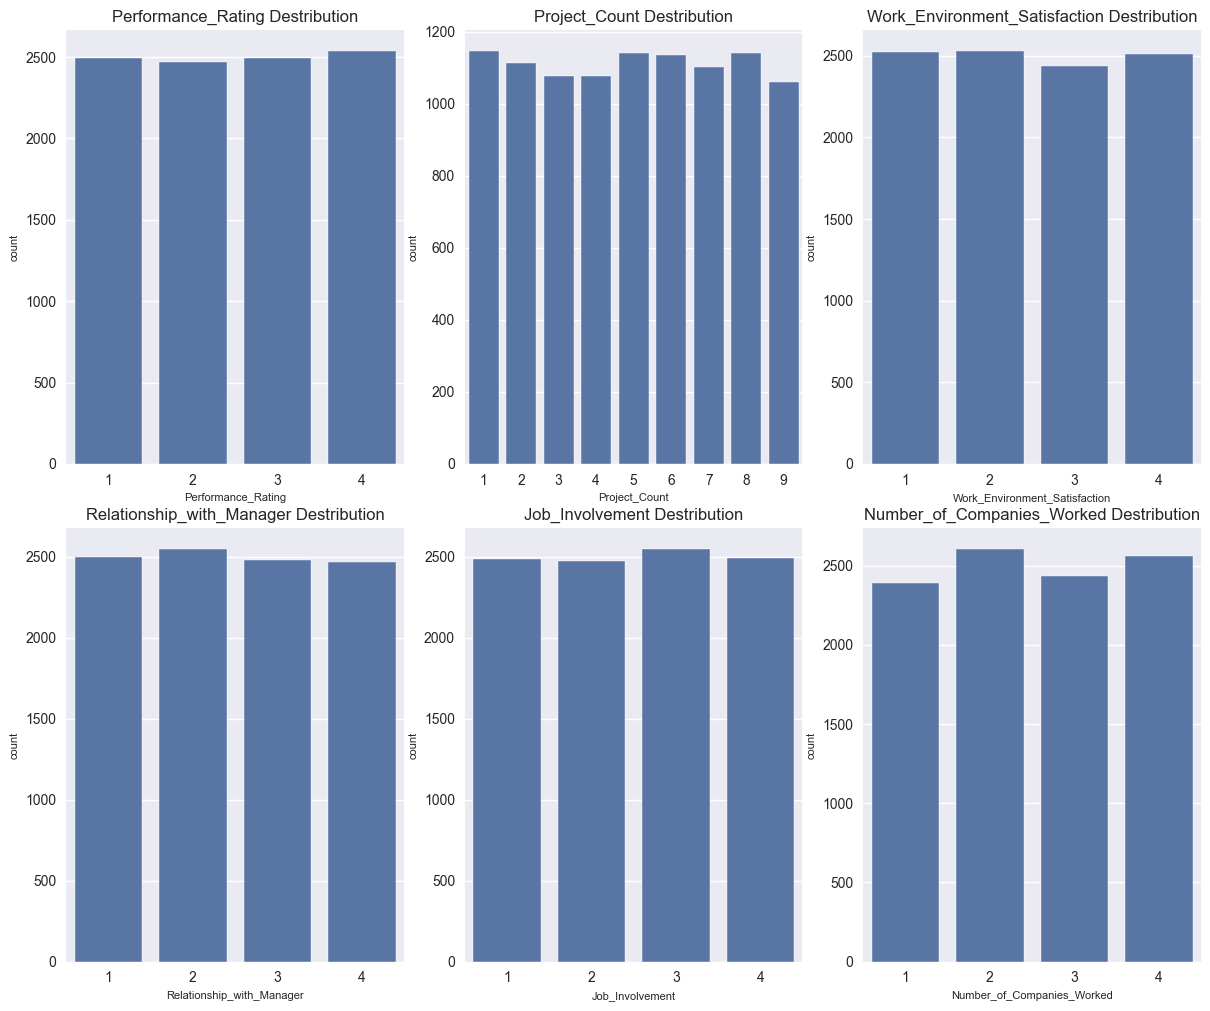

In [23]:
cols = ["Performance_Rating", "Project_Count" ,"Work_Environment_Satisfaction" , "Relationship_with_Manager" , "Job_Involvement" , "Number_of_Companies_Worked"]
fig , axes = plt.subplots(2 , 3 , figsize = (12 , 10))
axes = axes.flatten()

for i , col in enumerate(cols):
    sns.countplot(x = employees_data[col] , ax = axes[i])

    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

**Performance_Rating :** The performance rating for employees given by managers through review valued from 1 to 4.almost all the group of ratings of employees are same.

**Project_Count :** employees who 1, 5 , 6 , 8 number of project managed are high in dataset.that means most of the employees are have high work presure.

**Work_Environment_Satisfaction :** levels 1 , 2 are high means low number of employees are satisfaing in their work environment.

**Relationship_with_Manager :** 2 level employees high , employees not that mutch of relationship with manager in thier job.

**Job_Involvement :** 3 level of employees are high , almost  of the employees are equal both low and high.

**Number_of_Companies_Worked :** high number of employees worked by 2 and 4.

#### b) Chategorical features

In [24]:
cat_cols = employees_data.select_dtypes(include = "object").columns
cat_cols

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')

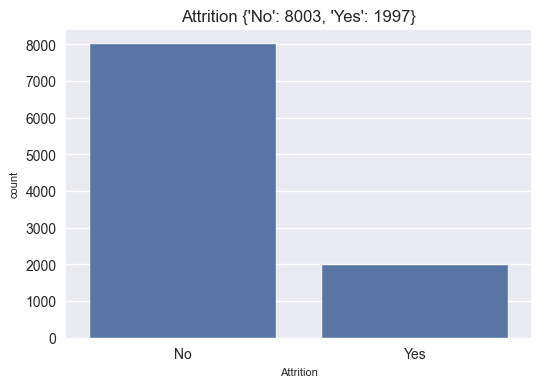

In [25]:
count = Counter(employees_data["Attrition"])
plt.figure(figsize = (6 , 4))
sns.countplot(x = employees_data["Attrition"])
plt.title(f"Attrition {dict(count)}")
plt.show()

**Attrition(target) :** target column is imbalanced , becouse non turnover employees records are higher than turnover employees records about (8003 > 1997).

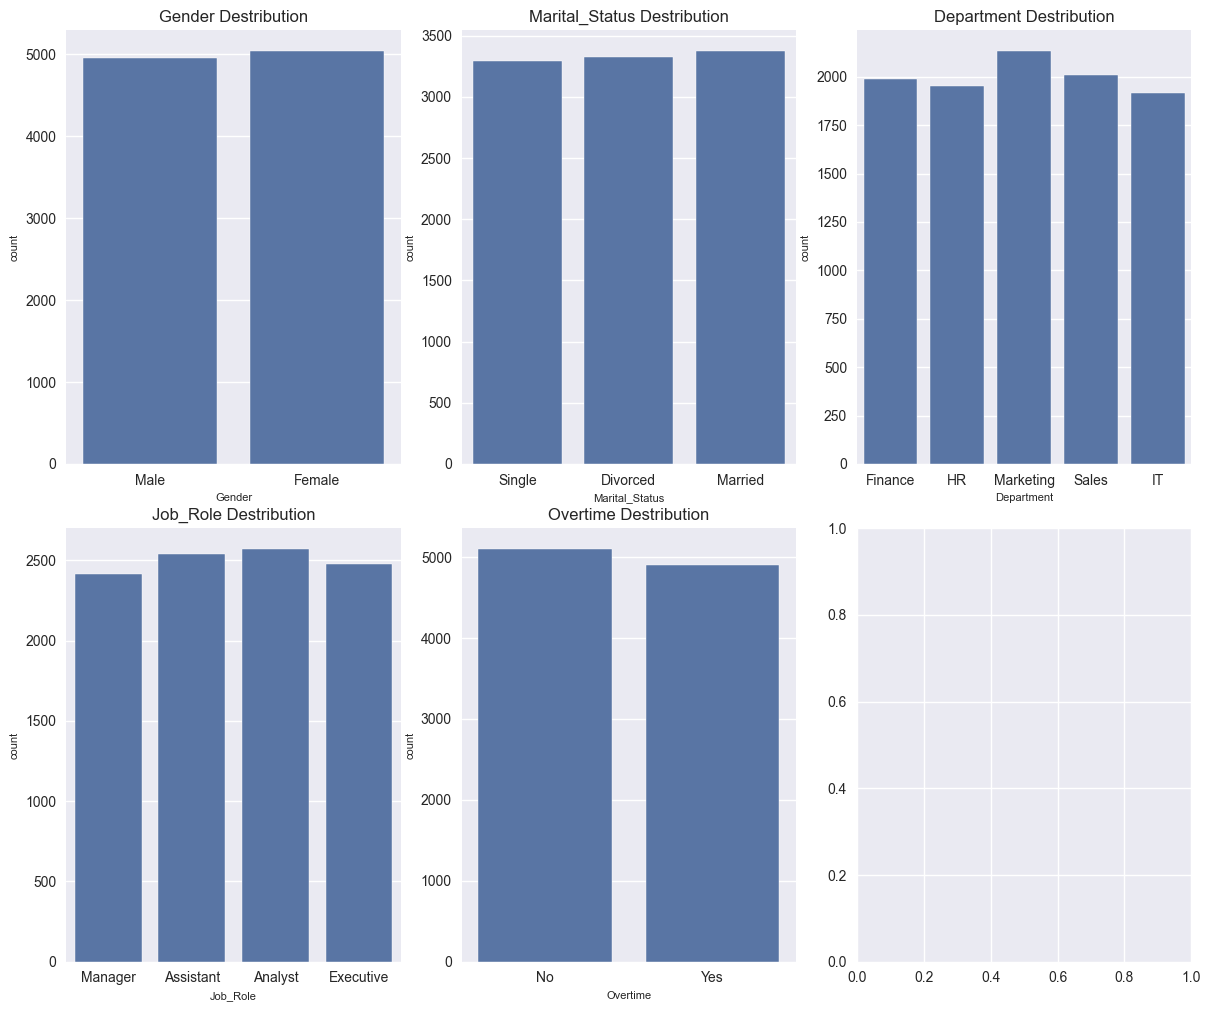

In [26]:
fig , axes = plt.subplots(2 , 3 , figsize = (12 , 10))
axes = axes.flatten()

for i , col in enumerate(cat_cols[:-1]):
    sns.countplot(x = employees_data[col] , ax = axes[i])

    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

**Gender :** it is one of the demographic feature.in dataset, both male and female employees destributions are almost same , with slictly diffrent ignore it.

**Marital_Status :** there are three groups single , married , divorce all are same destribution in dataset.

**Department :** in comapny there are five department where employees work they are Finance , HR , Marketing , Sales , It departments. Marketing , sales , finance are has high employees in company.

**job_role :** slictly higher employees are from Assistant , Analyst types of job roles.

**Overtime :** slictly difference in count of overtime Yes and No employees records in dataset.

#### ii) Bivariate Analysis(Relationships)

In [27]:
employees_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [28]:
def chie2_test(group1 , group2):
    cross = pd.crosstab(group1 , group2)
    stat , p , df , evidence = chi2_contingency(cross)

    n = cross.to_numpy().sum()
    cramers_v = np.sqrt(stat / (n * (min(cross.shape) - 1)))
    result = {
        "statistic" : stat,
        "P value" : p,
        "df" : df,
        "cramers_v" : cramers_v
    }
    segnificance_level = 0.05

    if p < segnificance_level:
        print("Reject Null Hypotheses , there is significant difference between two groups")
    else:
        print("Accept Null Hypotheses , there is no significant difference bewtween two groups")
    plt.figure(figsize = (5 , 3))
    sns.heatmap(cross , annot = True , annot_kws = {"size" : 10})
    plt.title("Contigency Table")
    plt.show()
    
    return result

Gender vs Attrition

Accept Null Hypotheses , there is no significant difference bewtween two groups


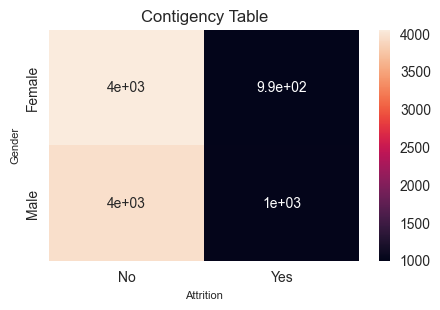

{'statistic': np.float64(0.5181128822276062), 'P value': np.float64(0.4716477846644431), 'df': 1, 'cramers_v': np.float64(0.007198005850425562)}
Marital_Status vs Attrition

Accept Null Hypotheses , there is no significant difference bewtween two groups


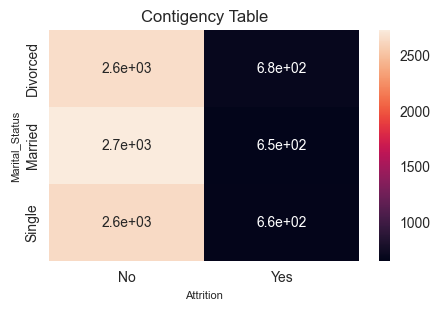

{'statistic': np.float64(1.9038982502734325), 'P value': np.float64(0.3859879509589678), 'df': 2, 'cramers_v': np.float64(0.013798181946450164)}
Department vs Attrition

Accept Null Hypotheses , there is no significant difference bewtween two groups


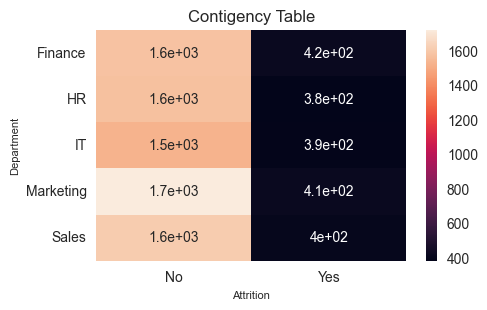

{'statistic': np.float64(1.9322774909297424), 'P value': np.float64(0.7482133205494339), 'df': 4, 'cramers_v': np.float64(0.013900638441919647)}
Job_Role vs Attrition

Reject Null Hypotheses , there is significant difference between two groups


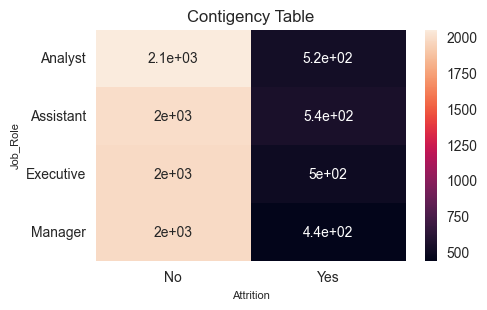

{'statistic': np.float64(9.022390509749386), 'P value': np.float64(0.028994668977611167), 'df': 3, 'cramers_v': np.float64(0.030037294335125104)}
Overtime vs Attrition

Accept Null Hypotheses , there is no significant difference bewtween two groups


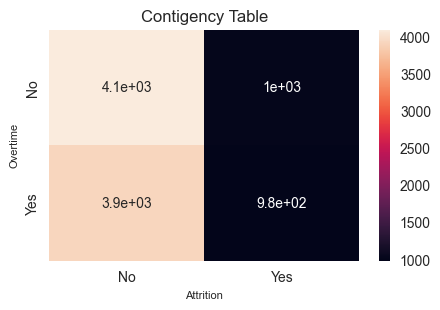

{'statistic': np.float64(0.052272680661176976), 'P value': np.float64(0.8191547991509125), 'df': 1, 'cramers_v': np.float64(0.0022863219515452536)}
Attrition vs Attrition

Reject Null Hypotheses , there is significant difference between two groups


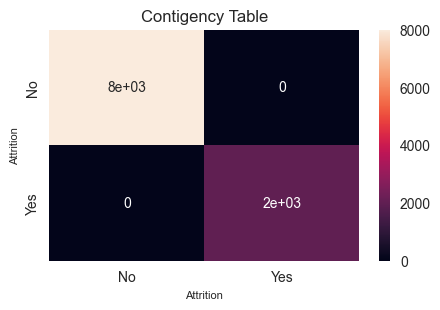

{'statistic': np.float64(9993.743936071967), 'P value': np.float64(0.0), 'df': 1, 'cramers_v': np.float64(0.9996871478653693)}


In [29]:
cat_cols = employees_data.select_dtypes(include = ["category" , "object"]).columns

for col in cat_cols:
    print(f"{col} vs Attrition\n")
    print(chie2_test(employees_data[col] , employees_data["Attrition"]))

In [30]:
employees_data["Attrition"].replace({
    "No" : 0,
    "Yes" : 1
} , inplace = True)

C:\Users\KISHORE\AppData\Local\Temp\ipykernel_20000\4013230837.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  employees_data["Attrition"].replace({
C:\Users\KISHORE\AppData\Local\Temp\ipykernel_20000\4013230837.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  employees_data["Attrition"].repl

In [31]:
num_cols = employees_data.select_dtypes(include = "int64").columns
corr = employees_data[num_cols].corr()["Attrition"].sort_values(ascending = False)
corr

Attrition                              1.0
Work_Life_Balance                  0.01523
Job_Involvement                    0.01495
Performance_Rating                 0.01186
Job_Level                          0.01142
Distance_From_Home                 0.01136
Age                               0.007798
Project_Count                     0.006802
Years_in_Current_Role              0.00512
Years_at_Company                  0.002682
Job_Satisfaction                  0.002142
Absenteeism                      0.0005138
Monthly_Income                   0.0001345
Training_Hours_Last_Year        -0.0005388
Years_Since_Last_Promotion       -0.001936
Average_Hours_Worked_Per_Week    -0.002457
Relationship_with_Manager        -0.004111
Hourly_Rate                      -0.005494
Number_of_Companies_Worked        -0.00823
Employee_ID                      -0.008766
Work_Environment_Satisfaction      -0.0111
Name: Attrition, dtype: float64

In [32]:
corr = list(corr.index)
select_cols = corr[:-8]

### Feature Selection and Spliting

In [37]:
x = employees_data[select_cols].drop(columns = "Attrition")
y = employees_data["Attrition"]

In [38]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , stratify = y , random_state = 42)

In [39]:
scaler = StandardScaler()

x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [36]:
'''smoteenn = SMOTEENN(random_state=42)
x_train_res, y_train_res = smoteenn.fit_resample(x_train_sc, y_train)'''

In [43]:
'''rus = RandomUnderSampler(random_state=42)

x_train_res, y_train_res = rus.fit_resample(x_train_sc, y_train)

print("Resampled Dataset Shape:", Counter(y_res))'''

Resampled Dataset Shape: Counter({0: 1598, 1: 1598})


In [196]:
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import OneSidedSelection
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import NeighbourhoodCleaningRule

In [68]:
'''nearmiss = NearMiss(version=1)

X_train_res, y_train_res = nearmiss.fit_resample(x_train_sc, y_train)

print("After NearMiss:", Counter(y_train_res))'''

After NearMiss: Counter({0: 1598, 1: 1598})


In [96]:
'''tomek = TomekLinks()

x_train_res, y_train_res = tomek.fit_resample(x_train_sc, y_train)

print("After Tomek Links:", Counter(y_train_res))'''

After Tomek Links: Counter({0: 5789, 1: 1598})


In [121]:
enn = EditedNearestNeighbours(n_neighbors=3)

x_train_res, y_train_res = enn.fit_resample(x_train_sc, y_train)

print("After ENN:", Counter(y_train_res))

After ENN: Counter({0: 3334, 1: 1598})


In [146]:
'''oss = OneSidedSelection(random_state=42)

x_train_res, y_train_res = oss.fit_resample(x_train_sc, y_train)

print("After OSS:", Counter(y_train_res))'''

After OSS: Counter({0: 5789, 1: 1598})


In [171]:
'''cnn = CondensedNearestNeighbour(random_state=42)

x_train_res, y_train_res = cnn.fit_resample(x_train_sc, y_train)

print("After CNN:", Counter(y_train_res))'''

After CNN: Counter({0: 2441, 1: 1598})


In [197]:
'''ncr = NeighbourhoodCleaningRule()

x_train_res, y_train_res = ncr.fit_resample(x_train_sc, y_train)

print("After NCR:", Counter(y_train_res))'''

After NCR: Counter({0: 3913, 1: 1598})


### Modeling

#### LightGBM (Light Gradient Boosting Machine) Model:

In [198]:
lgbm_model = LGBMClassifier(
    objective='binary',
    random_state=42
)


param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50],
    'subsample': [0.8, 1.0]
}


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [199]:
Rand_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

Rand_search.fit(x_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 1598, number of negative: 3913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 449
[LightGBM] [Info] Number of data points in the train set: 5511, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289966 -> initscore=-0.895551
[LightGBM] [Info] Start training from score -0.895551


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1], 'max_depth': [-1, 5, ...], 'n_estimators': [100, 200], 'num_leaves': [31, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [200]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.1745736499711522


C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [201]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 0.9929232444202504
Test Accuracy: 0.736

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.90      0.84      1601
           1       0.17      0.08      0.11       399

    accuracy                           0.74      2000
   macro avg       0.48      0.49      0.48      2000
weighted avg       0.67      0.74      0.70      2000


Confusion Matrix:

[[1439  162]
 [ 366   33]]


#### XGBClassifier

In [202]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)


param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

In [203]:
Rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

Rand_search.fit(x_train_res, y_train_res)

C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:54:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`

In [204]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.1573246144322416


In [205]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 0.8686263835964435
Test Accuracy: 0.756

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1601
           1       0.20      0.07      0.11       399

    accuracy                           0.76      2000
   macro avg       0.50      0.50      0.48      2000
weighted avg       0.68      0.76      0.71      2000


Confusion Matrix:

[[1483  118]
 [ 370   29]]


#### GradientBoostingClassifier

In [206]:
gb_model = GradientBoostingClassifier(random_state=42)


param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3, 4]
}

In [207]:
Rand_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

Rand_search.fit(x_train_res, y_train_res)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [208]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.036346744594434


In [209]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 0.7376156777354382
Test Accuracy: 0.7905

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1601
           1       0.22      0.02      0.04       399

    accuracy                           0.79      2000
   macro avg       0.51      0.50      0.46      2000
weighted avg       0.69      0.79      0.71      2000


Confusion Matrix:

[[1573   28]
 [ 391    8]]


CatBoostClassifier

#### CatBoostClassifier

In [210]:
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)


param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

In [211]:
Rand_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

Rand_search.fit(x_train_res, y_train_res)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 6, ...], 'iterations': [100, 200], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.03, 0.1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``c

In [212]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 8}
Best CV ROC-AUC: 0.15106931468580456


In [213]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 0.9883868626383596
Test Accuracy: 0.7425

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1601
           1       0.14      0.06      0.08       399

    accuracy                           0.74      2000
   macro avg       0.47      0.49      0.47      2000
weighted avg       0.67      0.74      0.70      2000


Confusion Matrix:

[[1462  139]
 [ 376   23]]


#### AdaBoostClassifier

In [214]:
base_estimator = RandomForestClassifier(
    n_estimators=10,   # keep small to avoid heavy computation
    max_depth=3,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    random_state=42
)


param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5],
    'estimator__max_depth': [1, 2, 3]
}

In [215]:
Rand_search = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

Rand_search.fit(x_train_res, y_train_res)

C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__max_depth': [1, 2, ...], 'learning_rate': [0.5, 1.0, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [216]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'n_estimators': 200, 'learning_rate': 1.5, 'estimator__max_depth': 3}
Best CV ROC-AUC: 0.27154231230991255


In [217]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 0.8354200689530031
Test Accuracy: 0.658

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      1601
           1       0.21      0.25      0.23       399

    accuracy                           0.66      2000
   macro avg       0.50      0.51      0.50      2000
weighted avg       0.68      0.66      0.67      2000


Confusion Matrix:

[[1216  385]
 [ 299  100]]


#### RandomizedSearchCV

In [218]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

Rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    cv=skf,
    scoring='f1',   # You can change to 'accuracy' or 'roc_auc'
    n_jobs=-1,
    verbose=2
)

Rand_search.fit(x_train_res, y_train_res)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [219]:
print("Best Parameters:", Rand_search.best_params_)
print("Best CV ROC-AUC:", Rand_search.best_score_)
best_model = Rand_search.best_estimator_
y_train_pred = best_model.predict(x_train_res)
y_test_pred = best_model.predict(x_test_sc)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV ROC-AUC: 0.026662313627158273


In [220]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))


Train Accuracy: 1.0
Test Accuracy: 0.794

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1601
           1       0.19      0.01      0.02       399

    accuracy                           0.79      2000
   macro avg       0.50      0.50      0.45      2000
weighted avg       0.68      0.79      0.71      2000


Confusion Matrix:

[[1584   17]
 [ 395    4]]
